# EDA — Customer Transactions
Exploratory analysis on the cleaned analytics tables in PostgreSQL.

**Tables used:**
- `analytics.fact_transactions`
- `analytics.dim_customers`
- `analytics.agg_by_customer`
- `analytics.agg_by_customer_product`
- `analytics.agg_by_product`

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\nicoa\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\nicoa\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\nicoa\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "C:\Users\nicoa\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "C:\Users\nicoa\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\nicoa\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\nicoa\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\nicoa\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "C:\Users\nicoa\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "C:\Users\nicoa\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found

In [2]:
# ── Connection ────────────────────────────────────────────────────────────────
# PostgreSQL is exposed on localhost:5433 (mapped from container port 5432)
DB_USER     = os.getenv('POSTGRES_USER',     'ebury_admin')
DB_PASSWORD = os.getenv('POSTGRES_PASSWORD', 'change_me')
DB_HOST     = os.getenv('POSTGRES_HOST',     'localhost')
DB_PORT     = os.getenv('POSTGRES_PORT',     '5433')
DB_NAME     = os.getenv('POSTGRES_DB',       'ebury_db')

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

def query(sql):
    return pd.read_sql(sql, engine)

In [3]:
# ── Load tables ───────────────────────────────────────────────────────────────
fact   = query('SELECT * FROM analytics.fact_transactions')
agg_c  = query('SELECT * FROM analytics.agg_by_customer')
agg_cp = query('SELECT * FROM analytics.agg_by_customer_product')
agg_p  = query('SELECT * FROM analytics.agg_by_product')

print(f'fact_transactions rows : {len(fact)}')
print(f'agg_by_customer rows   : {len(agg_c)}')
print(f'agg_by_product rows    : {len(agg_p)}')
fact.head()

fact_transactions rows : 61
agg_by_customer rows   : 10
agg_by_product rows    : 5


,transaction_id,customer_id,product_id,product_name,transaction_date,quantity,unit_price,tax,gross_amount,total_amount,tax_rate_pct,loaded_at
0,1001,501,101,Product A,2023-07-11,1,76.27,8.23,76.27,84.50,10.7906,2026-03-05 00:50:51.418295
1,1002,502,102,Product B,2023-07-12,3,119.16,17.06,357.48,374.54,4.7723,2026-03-05 00:50:51.418295
2,1003,503,103,Product C,2023-07-13,1,287.25,26.36,287.25,313.61,9.1767,2026-03-05 00:50:51.418295
3,1004,504,104,Product D,2023-07-13,2,115.46,25.39,230.92,256.31,10.9951,2026-03-05 00:50:51.418295
4,1005,505,100,Product E,2023-07-12,4,255.05,16.03,1020.20,1036.23,1.5713,2026-03-05 00:50:51.418295


## 1. Descriptive statistics

In [4]:
fact[['quantity', 'unit_price', 'tax', 'gross_amount', 'total_amount', 'tax_rate_pct']].describe().round(2)

,quantity,unit_price,tax,gross_amount,total_amount,tax_rate_pct
count,61.00,61.00,61.00,61.00,61.00,61.00
mean,2.84,187.82,18.80,545.67,564.47,5.53
std,1.39,69.73,7.28,361.49,362.96,5.09
min,1.00,52.97,5.43,76.27,84.50,0.63
25%,2.00,132.87,14.17,254.17,269.04,2.10
50%,3.00,182.98,19.47,419.92,441.13,3.92
75%,4.00,254.17,25.35,801.40,824.83,6.79
max,5.00,297.51,29.80,1445.20,1466.55,33.03


## 2. Correlation matrix — numeric fields

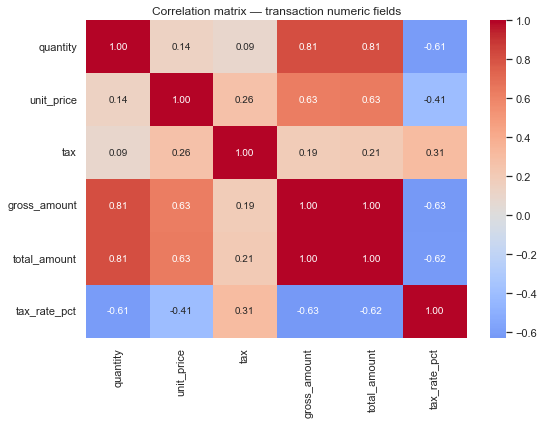

In [5]:
numeric_cols = ['quantity', 'unit_price', 'tax', 'gross_amount', 'total_amount', 'tax_rate_pct']
corr = fact[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix — transaction numeric fields')
plt.tight_layout()
plt.show()

## 3. Revenue by customer

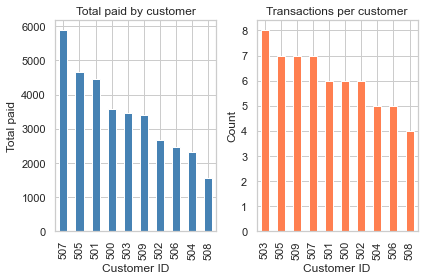

In [6]:
fig, axes = plt.subplots(1, 2)

agg_c.sort_values('total_paid', ascending=False).plot(
    kind='bar', x='customer_id', y='total_paid', ax=axes[0],
    color='steelblue', legend=False
)
axes[0].set_title('Total paid by customer')
axes[0].set_xlabel('Customer ID')
axes[0].set_ylabel('Total paid')

agg_c.sort_values('total_transactions', ascending=False).plot(
    kind='bar', x='customer_id', y='total_transactions', ax=axes[1],
    color='coral', legend=False
)
axes[1].set_title('Transactions per customer')
axes[1].set_xlabel('Customer ID')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Revenue and volume by product

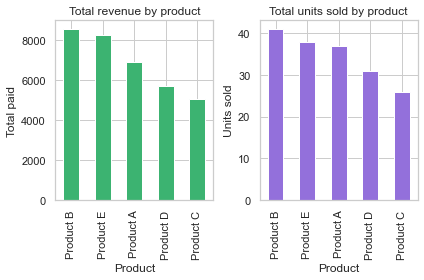

In [7]:
fig, axes = plt.subplots(1, 2)

agg_p.sort_values('total_paid', ascending=False).plot(
    kind='bar', x='product_name', y='total_paid', ax=axes[0],
    color='mediumseagreen', legend=False
)
axes[0].set_title('Total revenue by product')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Total paid')

agg_p.sort_values('total_products', ascending=False).plot(
    kind='bar', x='product_name', y='total_products', ax=axes[1],
    color='mediumpurple', legend=False
)
axes[1].set_title('Total units sold by product')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Units sold')

plt.tight_layout()
plt.show()

## 5. Unit price distribution by product

C:\Users\nicoa\AppData\Local\Temp/ipykernel_60896/3487800262.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fact, x='product_name', y='unit_price', ax=ax, palette='Set2')


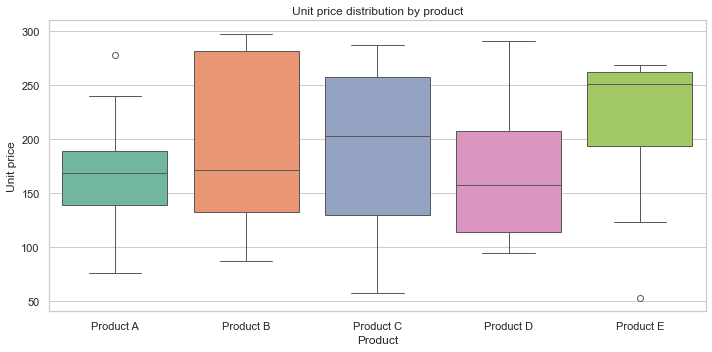

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=fact, x='product_name', y='unit_price', ax=ax, palette='Set2')
ax.set_title('Unit price distribution by product')
ax.set_xlabel('Product')
ax.set_ylabel('Unit price')
plt.tight_layout()
plt.show()

## 6. Scatter — quantity vs gross amount (should be linear)

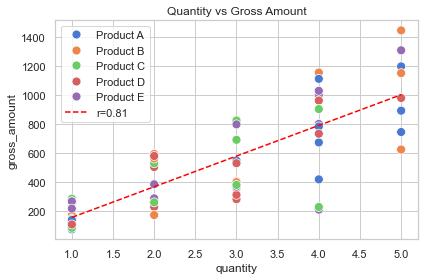

Pearson r = 0.8129 | p-value = 0.0000


In [9]:
fig, ax = plt.subplots()
sns.scatterplot(data=fact, x='quantity', y='gross_amount', hue='product_name', ax=ax, s=80)

# Regression line
slope, intercept, r, p, _ = stats.linregress(fact['quantity'], fact['gross_amount'])
x_line = pd.Series(range(1, 6))
ax.plot(x_line, slope * x_line + intercept, color='red', linestyle='--', label=f'r={r:.2f}')

ax.set_title('Quantity vs Gross Amount')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Pearson r = {r:.4f} | p-value = {p:.4f}')

## 7. Scatter — unit price vs tax

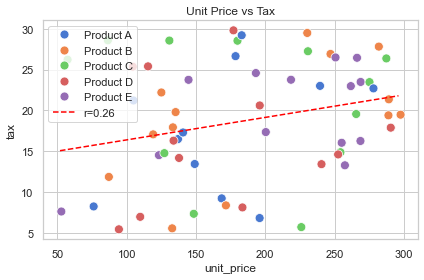

Pearson r = 0.2638 | p-value = 0.0399


In [10]:
fig, ax = plt.subplots()
sns.scatterplot(data=fact, x='unit_price', y='tax', hue='product_name', ax=ax, s=80)

slope, intercept, r, p, _ = stats.linregress(fact['unit_price'], fact['tax'])
x_line = pd.Series(range(int(fact['unit_price'].min()), int(fact['unit_price'].max())))
ax.plot(x_line, slope * x_line + intercept, color='red', linestyle='--', label=f'r={r:.2f}')

ax.set_title('Unit Price vs Tax')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Pearson r = {r:.4f} | p-value = {p:.4f}')

## 8. Heatmap — customer × product purchase frequency

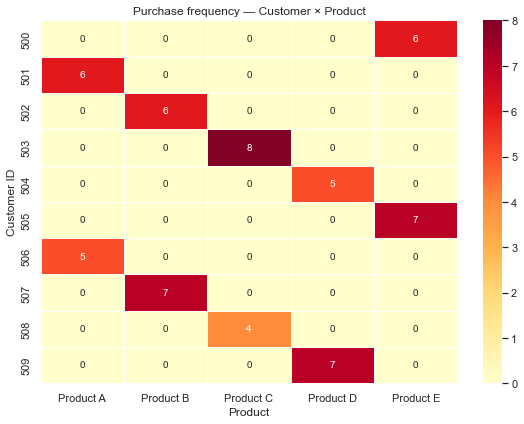

In [11]:
pivot = agg_cp.pivot(index='customer_id', columns='product_name', values='total_transactions').fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Purchase frequency — Customer × Product')
ax.set_xlabel('Product')
ax.set_ylabel('Customer ID')
plt.tight_layout()
plt.show()

## 9. Monthly transaction volume

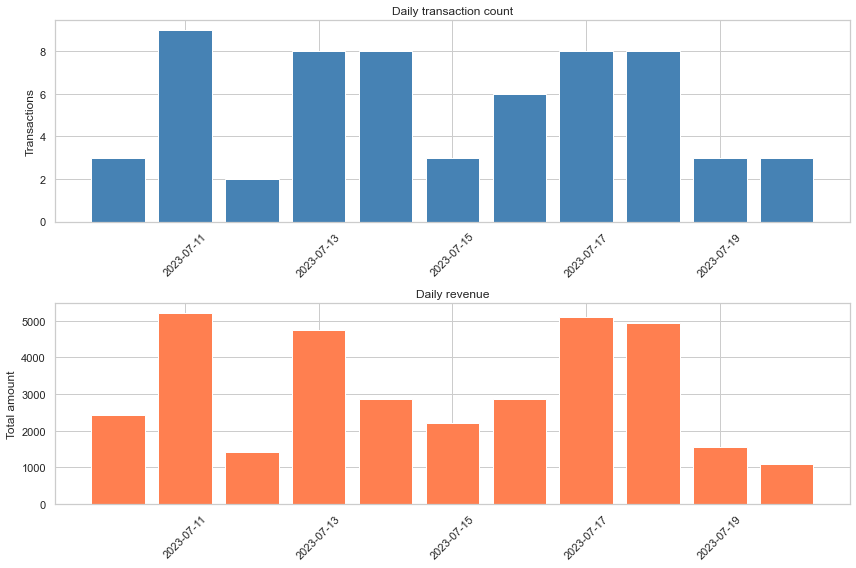

In [12]:
fact['transaction_date'] = pd.to_datetime(fact['transaction_date'])
daily = fact.groupby('transaction_date').agg(
    transactions=('transaction_id', 'count'),
    revenue=('total_amount', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].bar(daily['transaction_date'], daily['transactions'], color='steelblue')
axes[0].set_title('Daily transaction count')
axes[0].set_ylabel('Transactions')

axes[1].bar(daily['transaction_date'], daily['revenue'], color='coral')
axes[1].set_title('Daily revenue')
axes[1].set_ylabel('Total amount')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Key insights summary

In [13]:
print('=== KEY INSIGHTS ===')
print(f"Valid transactions       : {len(fact)}")
print(f"Unique customers         : {fact['customer_id'].nunique()}")
print(f"Unique products          : {fact['product_name'].nunique()}")
print(f"Date range               : {fact['transaction_date'].min()} → {fact['transaction_date'].max()}")
print(f"Total revenue            : {fact['total_amount'].sum():.2f}")
print(f"Total tax collected      : {fact['tax'].sum():.2f}")
print(f"Avg order value          : {fact['total_amount'].mean():.2f}")
print(f"Avg tax rate             : {fact['tax_rate_pct'].mean():.2f}%")
print()
print('Top customer by revenue  :')
print(agg_c.nlargest(3, 'total_paid')[['customer_id', 'total_paid', 'total_transactions']])
print()
print('Top product by revenue   :')
print(agg_p.nlargest(3, 'total_paid')[['product_name', 'total_paid', 'total_products']])

=== KEY INSIGHTS ===
Valid transactions       : 61
Unique customers         : 10
Unique products          : 5
Date range               : 2023-07-10 00:00:00 → 2023-07-20 00:00:00
Total revenue            : 34432.57
Total tax collected      : 1146.90
Avg order value          : 564.47
Avg tax rate             : 5.53%

Top customer by revenue  :
   customer_id  total_paid  total_transactions
7          507     5879.43                   7
5          505     4653.61                   7
1          501     4457.18                   6

Top product by revenue   :
  product_name  total_paid  total_products
2    Product B     8546.29              41
0    Product E     8230.08              38
1    Product A     6922.54              37
